✅ LSTM Input shape: (2878, 2, 31), Target shape: (2878,)
📊 Train samples: 2302, Test samples: 576


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 64)             │        24,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,689 (104.25 KB)

 Trainable params: 26,689 (104.25 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.1580 - val_loss: 0.0209
Epoch 2/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0276 - val_loss: 0.0242
Epoch 3/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0270 - val_loss: 0.0184
Epoch 4/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0251 - val_loss: 0.0193
Epoch 5/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0244 - val_loss: 0.0186
Epoch 6/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0254 - val_loss: 0.0186
Epoch 7/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0239 - val_loss: 0.0188
Epoch 8/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0237 - val_loss: 0.0188
Epoch 9/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0233 - val_loss: 0.0185
Epoch 10/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0244 - val_loss: 0.0195
Epoch 11/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0228 - val_loss: 0.0245
Epoch 12/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms

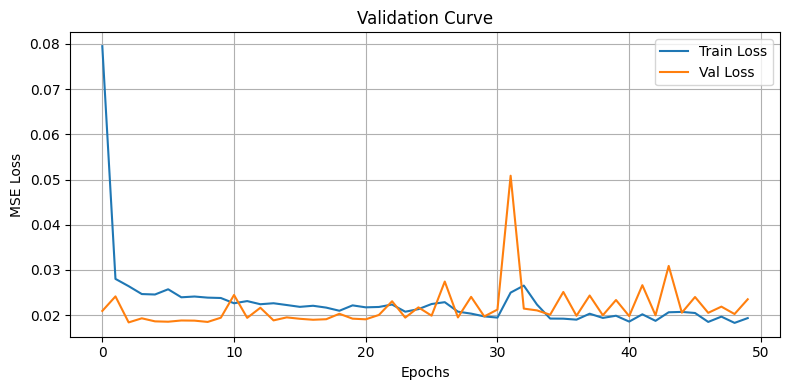

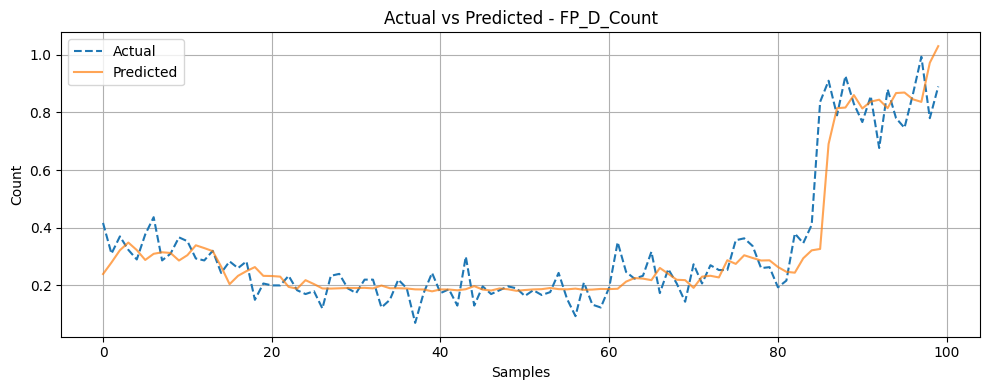

In [ ]:
#lag=2


import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# ---------------- STEP 1: LOAD AND DOWNSAMPLE ----------------
file_path = "junction_data_race_course.csv"
df = pd.read_csv(file_path)

# Downsample every 5 minutes (every 300 seconds)
df_downsampled = df.groupby(np.arange(len(df)) // 300).mean(numeric_only=True).reset_index(drop=True)

# ---------------- STEP 2: CREATE LAGGED SEQUENCES ----------------
def create_lagged_sequences(data, target_col="FP_D_Count", lag=2):
    numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    if target_col not in numeric_cols:
        raise ValueError(f"{target_col} not in numeric columns")

    # Normalize all features
    scaler_X = MinMaxScaler()
    data_scaled = pd.DataFrame(scaler_X.fit_transform(data[numeric_cols]), columns=numeric_cols)

    sequences, targets = [], []
    for i in range(lag, len(data_scaled)):
        seq = data_scaled.iloc[i - lag:i].values
        target = data[target_col].iloc[i]  # original (not scaled) for evaluation
        sequences.append(seq)
        targets.append(target)

    X = np.array(sequences)
    y = np.array(targets)

    print(f"✅ LSTM Input shape: {X.shape}, Target shape: {y.shape}")
    return X, y

# ---------------- STEP 3: TRAIN AND EVALUATE LSTM ----------------
def run_lstm_pipeline(data, lag=2, target_col="FP_D_Count"):
    X, y = create_lagged_sequences(data, target_col=target_col, lag=lag)

    # Train-test split (shuffle=False for time-series)
    split_index = int(0.8 * len(X))
    X_train, X_test = X[:split_index], X[split_index:]
    y_train, y_test = y[:split_index], y[split_index:]

    print(f"📊 Train samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

    # Build LSTM model
    model = Sequential()
    model.add(LSTM(64, input_shape=(X.shape[1], X.shape[2]), return_sequences=False))
    model.add(Dropout(0.3))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1))

    model.compile(optimizer='adam', loss='mse')
    print(model.summary())

    # Train model
    history = model.fit(X_train, y_train, epochs=50, batch_size=16,
                        validation_split=0.1, verbose=1, shuffle=False)

    # Predict
    y_pred = model.predict(X_test).flatten()

    # Evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("\n📈 Final Evaluation:")
    print(f"MAE : {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²  : {r2:.2f}")

    # ---------------- PLOTS ----------------
    # Validation Curve
    plt.figure(figsize=(8, 4))
    plt.plot(history.history['loss'], label="Train Loss")
    plt.plot(history.history['val_loss'], label="Val Loss")
    plt.title("Validation Curve")
    plt.xlabel("Epochs")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Actual vs Predicted Plot
    plt.figure(figsize=(10, 4))
    plt.plot(y_test[:100], label="Actual", linestyle='--')
    plt.plot(y_pred[:100], label="Predicted", alpha=0.7)
    plt.title("Actual vs Predicted - FP_D_Count")
    plt.xlabel("Samples")
    plt.ylabel("Count")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ---------------- RUN ----------------
run_lstm_pipeline(df_downsampled, lag=2)


✅ LSTM Input shape: (286, 2, 31), Target shape: (286,)
📊 Train samples: 228, Test samples: 58


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        24,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,689 (104.25 KB)

 Trainable params: 26,689 (104.25 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 0.1940 - val_loss: 0.0413
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0433 - val_loss: 0.0485
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0425 - val_loss: 0.0493
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0298 - val_loss: 0.0375
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0285 - val_loss: 0.0347
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0298 - val_loss: 0.0359
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0279 - val_loss: 0.0345
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0275 - val_loss: 0.0340
Epoch 9/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0257 - val_loss: 0.0343
Epoch 10/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0216 - val_loss: 0.0335
Epoch 11/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0239 - val_loss: 0.0335
Epoch 12/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss:

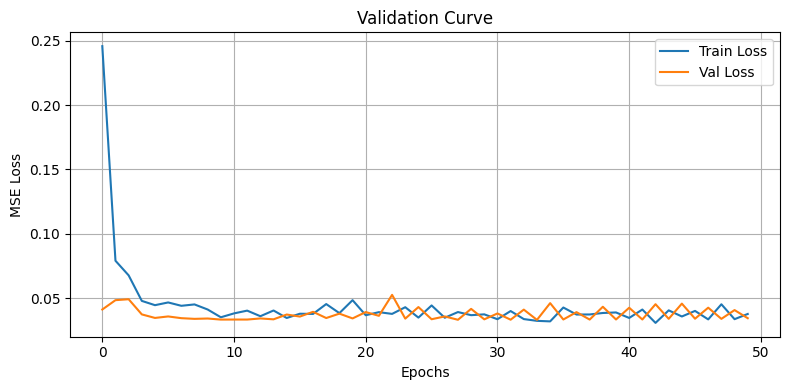

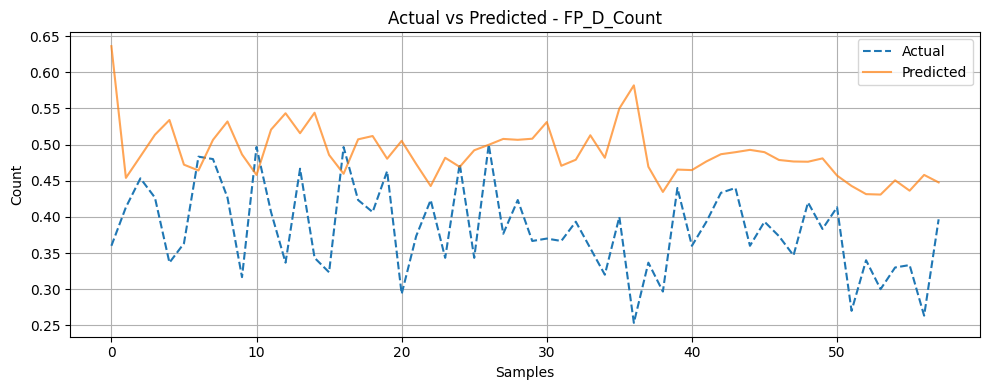

In [3]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# ---------------- STEP 1: LOAD AND DOWNSAMPLE ----------------
file_path = "junction_data_race_course (1).csv"
df = pd.read_csv(file_path)

# Downsample every 5 minutes (every 300 seconds)
df_downsampled = df.groupby(np.arange(len(df)) // 300).mean(numeric_only=True).reset_index(drop=True)

# ---------------- STEP 2: CREATE LAGGED SEQUENCES ----------------
def create_lagged_sequences(data, target_col="FP_D_Count", lag=5):
    numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    if target_col not in numeric_cols:
        raise ValueError(f"{target_col} not in numeric columns")

    # Normalize all features
    scaler_X = MinMaxScaler()
    data_scaled = pd.DataFrame(scaler_X.fit_transform(data[numeric_cols]), columns=numeric_cols)

    sequences, targets = [], []
    for i in range(lag, len(data_scaled)):
        seq = data_scaled.iloc[i - lag:i].values
        target = data[target_col].iloc[i]  # original (not scaled) for evaluation
        sequences.append(seq)
        targets.append(target)

    X = np.array(sequences)
    y = np.array(targets)

    print(f"✅ LSTM Input shape: {X.shape}, Target shape: {y.shape}")
    return X, y

# ---------------- STEP 3: TRAIN AND EVALUATE LSTM ----------------
def run_lstm_pipeline(data, lag=5, target_col="FP_D_Count"):
    X, y = create_lagged_sequences(data, target_col=target_col, lag=lag)

    # Train-test split (shuffle=False for time-series)
    split_index = int(0.8 * len(X))
    X_train, X_test = X[:split_index], X[split_index:]
    y_train, y_test = y[:split_index], y[split_index:]

    print(f"📊 Train samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

    # Build LSTM model
    model = Sequential()
    model.add(LSTM(64, input_shape=(X.shape[1], X.shape[2]), return_sequences=False))
    model.add(Dropout(0.3))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1))

    model.compile(optimizer='adam', loss='mse')
    print(model.summary())

    # Train model
    history = model.fit(X_train, y_train, epochs=50, batch_size=16,
                        validation_split=0.1, verbose=1, shuffle=False)

    # Predict
    y_pred = model.predict(X_test).flatten()

    # Evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("\n📈 Final Evaluation:")
    print(f"MAE : {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²  : {r2:.2f}")

    # ---------------- PLOTS ----------------
    # Validation Curve
    plt.figure(figsize=(8, 4))
    plt.plot(history.history['loss'], label="Train Loss")
    plt.plot(history.history['val_loss'], label="Val Loss")
    plt.title("Validation Curve")
    plt.xlabel("Epochs")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Actual vs Predicted Plot
    plt.figure(figsize=(10, 4))
    plt.plot(y_test[:100], label="Actual", linestyle='--')
    plt.plot(y_pred[:100], label="Predicted", alpha=0.7)
    plt.title("Actual vs Predicted - FP_D_Count")
    plt.xlabel("Samples")
    plt.ylabel("Count")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ---------------- RUN ----------------
run_lstm_pipeline(df_downsampled, lag=2)


✅ Lagged DataFrame shape: (2875, 155), Target shape: (2875,)
📊 Train samples: 2300, Test samples: 575

🔍 X_train.columns:
['Time_t-5', 'FP_A_Count_t-5', 'FP_A_QueuePct_t-5', 'FP_A_Speed_t-5', 'FP_B_Count_t-5', 'FP_B_QueuePct_t-5', 'FP_B_Speed_t-5', 'FP_C_Count_t-5', 'FP_C_QueuePct_t-5', 'FP_C_Speed_t-5', 'FP_D_Count_t-5', 'FP_D_QueuePct_t-5', 'FP_D_Speed_t-5', 'KR_Circle_Count_t-5', 'KR_Circle_QueuePct_t-5', 'KR_Circle_Speed_t-5', 'KG_Road_Count_t-5', 'KG_Road_QueuePct_t-5', 'KG_Road_Speed_t-5', 'District_Office_Count_t-5', 'District_Office_QueuePct_t-5', 'District_Office_Speed_t-5', 'Anand_Rao_Jnc_Count_t-5', 'Anand_Rao_Jnc_QueuePct_t-5', 'Anand_Rao_Jnc_Speed_t-5', 'Race_Course_Jnc_Count_t-5', 'Race_Course_Jnc_QueuePct_t-5', 'Race_Course_Jnc_Speed_t-5', 'Palace_Road_Jnc_Count_t-5', 'Palace_Road_Jnc_QueuePct_t-5', 'Palace_Road_Jnc_Speed_t-5', 'Time_t-4', 'FP_A_Count_t-4', 'FP_A_QueuePct_t-4', 'FP_A_Speed_t-4', 'FP_B_Count_t-4', 'FP_B_QueuePct_t-4', 'FP_B_Speed_t-4', 'FP_C_Count_t-4', '

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_7 (LSTM)                   │ (None, 64)             │        24,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,689 (104.25 KB)

 Trainable params: 26,689 (104.25 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0838 - val_loss: 0.0277
Epoch 2/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0296 - val_loss: 0.0236
Epoch 3/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0267 - val_loss: 0.0251
Epoch 4/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0248 - val_loss: 0.0218
Epoch 5/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0253 - val_loss: 0.0228
Epoch 6/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0258 - val_loss: 0.0268
Epoch 7/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0237 - val_loss: 0.0234
Epoch 8/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0247 - val_loss: 0.0241
Epoch 9/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0243 - val_loss: 0.0205
Epoch 10/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0225 - val_loss: 0.0201
Epoch 11/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0238 - val_loss: 0.0199
Epoch 12/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms

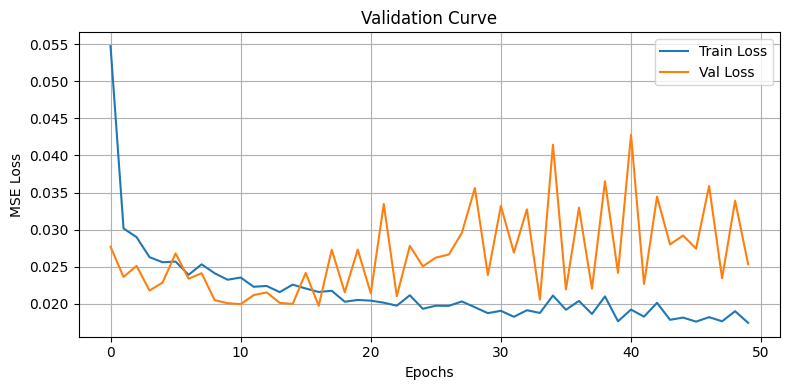

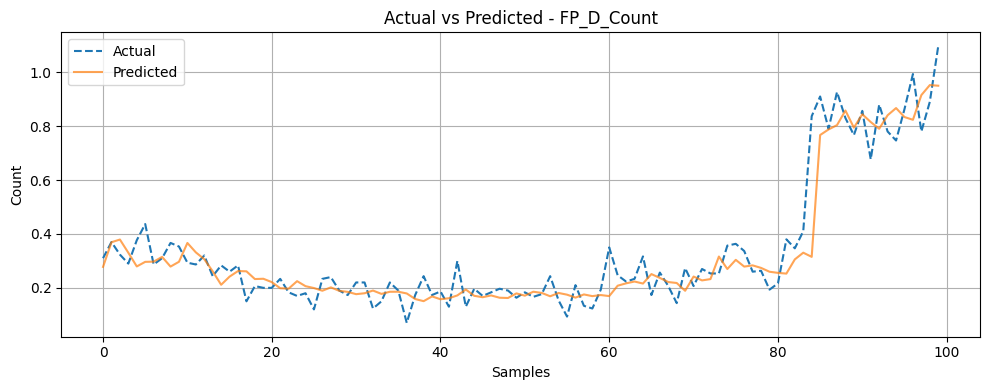

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# ---------------- STEP 1: LOAD AND DOWNSAMPLE ----------------
file_path = "junction_data_race_course.csv"
df = pd.read_csv(file_path)

# Downsample every 5 minutes (every 300 seconds)
df_downsampled = df.groupby(np.arange(len(df)) // 300).mean(numeric_only=True).reset_index(drop=True)

# ---------------- STEP 2: CREATE LAGGED SEQUENCES ----------------
def create_lagged_sequences(data, target_col="FP_D_Count", lag=5):
    numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    if target_col not in numeric_cols:
        raise ValueError(f"{target_col} not in numeric columns")

    # Normalize all features
    scaler_X = MinMaxScaler()
    data_scaled = pd.DataFrame(scaler_X.fit_transform(data[numeric_cols]), columns=numeric_cols)

    all_sequences = []
    targets = []

    for i in range(lag, len(data_scaled)):
        lagged_features = []
        for j in range(lag, 0, -1):
            lagged_features.extend(data_scaled.iloc[i - j].values)
        all_sequences.append(lagged_features)
        targets.append(data[target_col].iloc[i])  # original (not scaled) for evaluation

    # Create column names like "FP_D_Count_t-1", "FP_D_Count_t-2", ...
    feature_names = []
    for j in range(lag, 0, -1):
        feature_names.extend([f"{col}_t-{j}" for col in data_scaled.columns])

    X_df = pd.DataFrame(all_sequences, columns=feature_names)
    y = np.array(targets)

    print(f"✅ Lagged DataFrame shape: {X_df.shape}, Target shape: {y.shape}")
    return X_df, y

# ---------------- STEP 3: TRAIN AND EVALUATE LSTM ----------------
def run_lstm_pipeline(data, lag=5, target_col="FP_D_Count"):
    X_df, y = create_lagged_sequences(data, target_col=target_col, lag=lag)

    # Train-test split (no shuffle for time-series)
    split_index = int(0.8 * len(X_df))
    X_train_df, X_test_df = X_df[:split_index], X_df[split_index:]
    y_train, y_test = y[:split_index], y[split_index:]

    print(f"📊 Train samples: {X_train_df.shape[0]}, Test samples: {X_test_df.shape[0]}")
    print("\n🔍 X_train.columns:")
    print(X_train_df.columns.tolist())
    print("\n🔍 X_test.columns:")
    print(X_test_df.columns.tolist())


    # Reshape to (samples, timesteps, features)
    num_features = int(X_train_df.shape[1] / lag)
    X_train = X_train_df.values.reshape((-1, lag, num_features))
    X_test = X_test_df.values.reshape((-1, lag, num_features))

    # Build LSTM model
    model = Sequential()
    model.add(LSTM(64, input_shape=(lag, num_features), return_sequences=False))
    model.add(Dropout(0.3))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1))

    model.compile(optimizer='adam', loss='mse')
    print(model.summary())

    # Train model
    history = model.fit(X_train, y_train, epochs=50, batch_size=16,
                        validation_split=0.1, verbose=1, shuffle=False)

    # Predict
    y_pred = model.predict(X_test).flatten()

    # Evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("\n📈 Final Evaluation:")
    print(f"MAE : {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²  : {r2:.2f}")

    # ---------------- PLOTS ----------------
    plt.figure(figsize=(8, 4))
    plt.plot(history.history['loss'], label="Train Loss")
    plt.plot(history.history['val_loss'], label="Val Loss")
    plt.title("Validation Curve")
    plt.xlabel("Epochs")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(y_test[:100], label="Actual", linestyle='--')
    plt.plot(y_pred[:100], label="Predicted", alpha=0.7)
    plt.title("Actual vs Predicted - FP_D_Count")
    plt.xlabel("Samples")
    plt.ylabel("Count")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ---------------- RUN ----------------
run_lstm_pipeline(df_downsampled, lag=5)
